# Banxico SIE API — Data Exploration
## Bronze Layer Analysis

This notebook explores the raw structure of Banxico SIE API responses
before defining Silver layer transformation rules.

Series under analysis:
- **SF43718** — USD/MXN FIX exchange rate (daily)
- **SF61745** — TIIE 28-day / target rate (daily)
- **SP1**     — INPC consumer price index (monthly)

Key questions:
1. What does the raw JSON structure look like?
2. What data types and formats does Banxico use?
3. Are there missing values or special characters?
4. Do series have gaps (weekends, holidays)?
5. What transformations are needed for Silver?

In [12]:
import json
import os
from datetime import datetime, timedelta, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import requests
from dotenv import load_dotenv

load_dotenv()

BANXICO_BASE_URL = "https://www.banxico.org.mx/SieAPIRest/service/v1/series"
BANXICO_TOKEN    = os.getenv("BANXICO_TOKEN")

SERIES = {
    "tipo_de_cambio": {"id": "SF43718", "frequency": "daily"},
    "tiie_28":        {"id": "SF61745", "frequency": "daily"},
    "inpc":           {"id": "SP1",     "frequency": "monthly"},
}

# Two years of history for meaningful trend analysis
START_DATE = "2023-01-01"
END_DATE   = "2024-12-31"

print(f"Token configured: {'yes' if BANXICO_TOKEN else 'NO — rate limits apply'}")
print(f"Analysis window : {START_DATE} → {END_DATE}")

Token configured: yes
Analysis window : 2023-01-01 → 2024-12-31


## 1. Raw API Response

Inspect the exact JSON structure returned by Banxico before any transformation.
This determines the parsing logic in the Silver layer.

In [13]:
def fetch_serie(serie_id: str, start_date: str, end_date: str) -> dict:
    url     = f"{BANXICO_BASE_URL}/{serie_id}/datos/{start_date}/{end_date}"
    headers = {"Bmx-Token": BANXICO_TOKEN} if BANXICO_TOKEN else {}
    response = requests.get(url, headers=headers, timeout=30)
    response.raise_for_status()
    return response.json()

# Inspect SF43718 raw response (short window for readability)
raw_fx = fetch_serie("SF43718", "2024-01-01", "2024-01-15")
print(json.dumps(raw_fx, indent=2, ensure_ascii=False))

{
  "bmx": {
    "series": [
      {
        "idSerie": "SF43718",
        "titulo": "Tipo de cambio                                          Pesos por dólar E.U.A. Tipo de cambio para solventar obligaciones denominadas en moneda extranjera Fecha de determinación (FIX)",
        "datos": [
          {
            "fecha": "02/01/2024",
            "dato": "17.0297"
          },
          {
            "fecha": "03/01/2024",
            "dato": "17.0492"
          },
          {
            "fecha": "04/01/2024",
            "dato": "17.0458"
          },
          {
            "fecha": "05/01/2024",
            "dato": "16.8987"
          },
          {
            "fecha": "08/01/2024",
            "dato": "16.8133"
          },
          {
            "fecha": "09/01/2024",
            "dato": "16.9347"
          },
          {
            "fecha": "10/01/2024",
            "dato": "16.9912"
          },
          {
            "fecha": "11/01/2024",
            "dato": "16.9898"
  

### Observations — Raw Structure

- Response is nested under `bmx.series[]`
- Each series object contains `idSerie`, `titulo`, and `datos[]`
- Each data point has exactly two fields: `fecha` and `dato`
- **Date format**: `dd/mm/yyyy` — requires conversion to `datetime`
- **Values**: strings, not numbers — require casting to `float`
- **Title field** (`titulo`): contains extra whitespace — cosmetic issue only

In [14]:
def parse_banxico_response(raw: dict, serie_name: str) -> pd.DataFrame:
    """
    Parse raw Banxico JSON response into a clean DataFrame.
    Applies minimal transformations — only what's needed to work with the data.
    Full cleaning happens in Silver.
    """
    series = raw.get("bmx", {}).get("series", [])

    if not series or "datos" not in series[0]:
        print(f"WARNING: No data found for {serie_name}")
        return pd.DataFrame()

    serie  = series[0]
    df     = pd.DataFrame(serie["datos"])

    # Minimal parsing for exploration — Silver will enforce full schema
    df["fecha"]      = pd.to_datetime(df["fecha"], format="%d/%m/%Y")
    df["dato"]       = pd.to_numeric(df["dato"], errors="coerce")
    df["serie_id"]   = serie["idSerie"]
    df["serie_name"] = serie_name
    df["titulo"]     = serie["titulo"].strip()

    return df.rename(columns={"fecha": "date", "dato": "value"})


# Parse all three series
raw_data = {}
dfs      = {}

for serie_name, serie_info in SERIES.items():
    serie_id = serie_info["id"]
    raw      = fetch_serie(serie_id, START_DATE, END_DATE)
    raw_data[serie_name] = raw
    dfs[serie_name]      = parse_banxico_response(raw, serie_name)
    print(f"{serie_name}: {len(dfs[serie_name])} rows")

tipo_de_cambio: 502 rows
tiie_28: 727 rows
inpc: 24 rows


## 2. DataFrame Structure & Data Types

In [15]:
for serie_name, df in dfs.items():
    print(f"\n{'='*50}")
    print(f"Serie: {serie_name}")
    print(f"Shape: {df.shape}")
    print(f"\nDtypes:\n{df.dtypes}")
    print(f"\nSample:\n{df.head(3)}")
    print(f"\nValue range: {df['value'].min():.4f} → {df['value'].max():.4f}")


Serie: tipo_de_cambio
Shape: (502, 5)

Dtypes:
date          datetime64[us]
value                float64
serie_id                 str
serie_name               str
titulo                   str
dtype: object

Sample:
        date    value serie_id      serie_name  \
0 2023-01-02  19.4883  SF43718  tipo_de_cambio   
1 2023-01-03  19.4220  SF43718  tipo_de_cambio   
2 2023-01-04  19.3568  SF43718  tipo_de_cambio   

                                              titulo  
0  Tipo de cambio                                ...  
1  Tipo de cambio                                ...  
2  Tipo de cambio                                ...  

Value range: 16.3357 → 20.7862

Serie: tiie_28
Shape: (727, 5)

Dtypes:
date          datetime64[us]
value                float64
serie_id                 str
serie_name               str
titulo                   str
dtype: object

Sample:
        date  value serie_id serie_name         titulo
0 2023-01-01   10.5  SF61745    tiie_28  Tasa objetivo
1 2023-01-02

## 3. Data Quality — Nulls, Gaps & Special Values

In [16]:
for serie_name, df in dfs.items():
    print(f"\n{'='*50}")
    print(f"Serie: {serie_name}")
    print(f"Null values     : {df['value'].isnull().sum()}")
    print(f"Date range      : {df['date'].min().date()} → {df['date'].max().date()}")
    print(f"Total rows      : {len(df)}")

    # Check for date gaps
    if serie_info["frequency"] == "daily":
        expected_days = pd.bdate_range(df["date"].min(), df["date"].max())
        missing_dates = set(expected_days) - set(df["date"])
        print(f"Missing business days: {len(missing_dates)}")
        if missing_dates:
            print(f"  First 5: {sorted(missing_dates)[:5]}")


Serie: tipo_de_cambio
Null values     : 0
Date range      : 2023-01-02 → 2024-12-31
Total rows      : 502

Serie: tiie_28
Null values     : 0
Date range      : 2023-01-01 → 2024-12-31
Total rows      : 727

Serie: inpc
Null values     : 0
Date range      : 2023-01-01 → 2024-12-01
Total rows      : 24


### Observations — Data Quality

- **SF43718 (FIX)**: No weekends — only business days. Gaps on Mexican holidays expected.
- **SF61745 (TIIE)**: Includes weekends — Banxico publishes target rate for all calendar days.
  → Silver decision: keep all days or align to business days only?
- **SP1 (INPC)**: One observation per month, always on the 1st.
  → No nulls expected if we query closed months only.

## 4. Visual Analysis

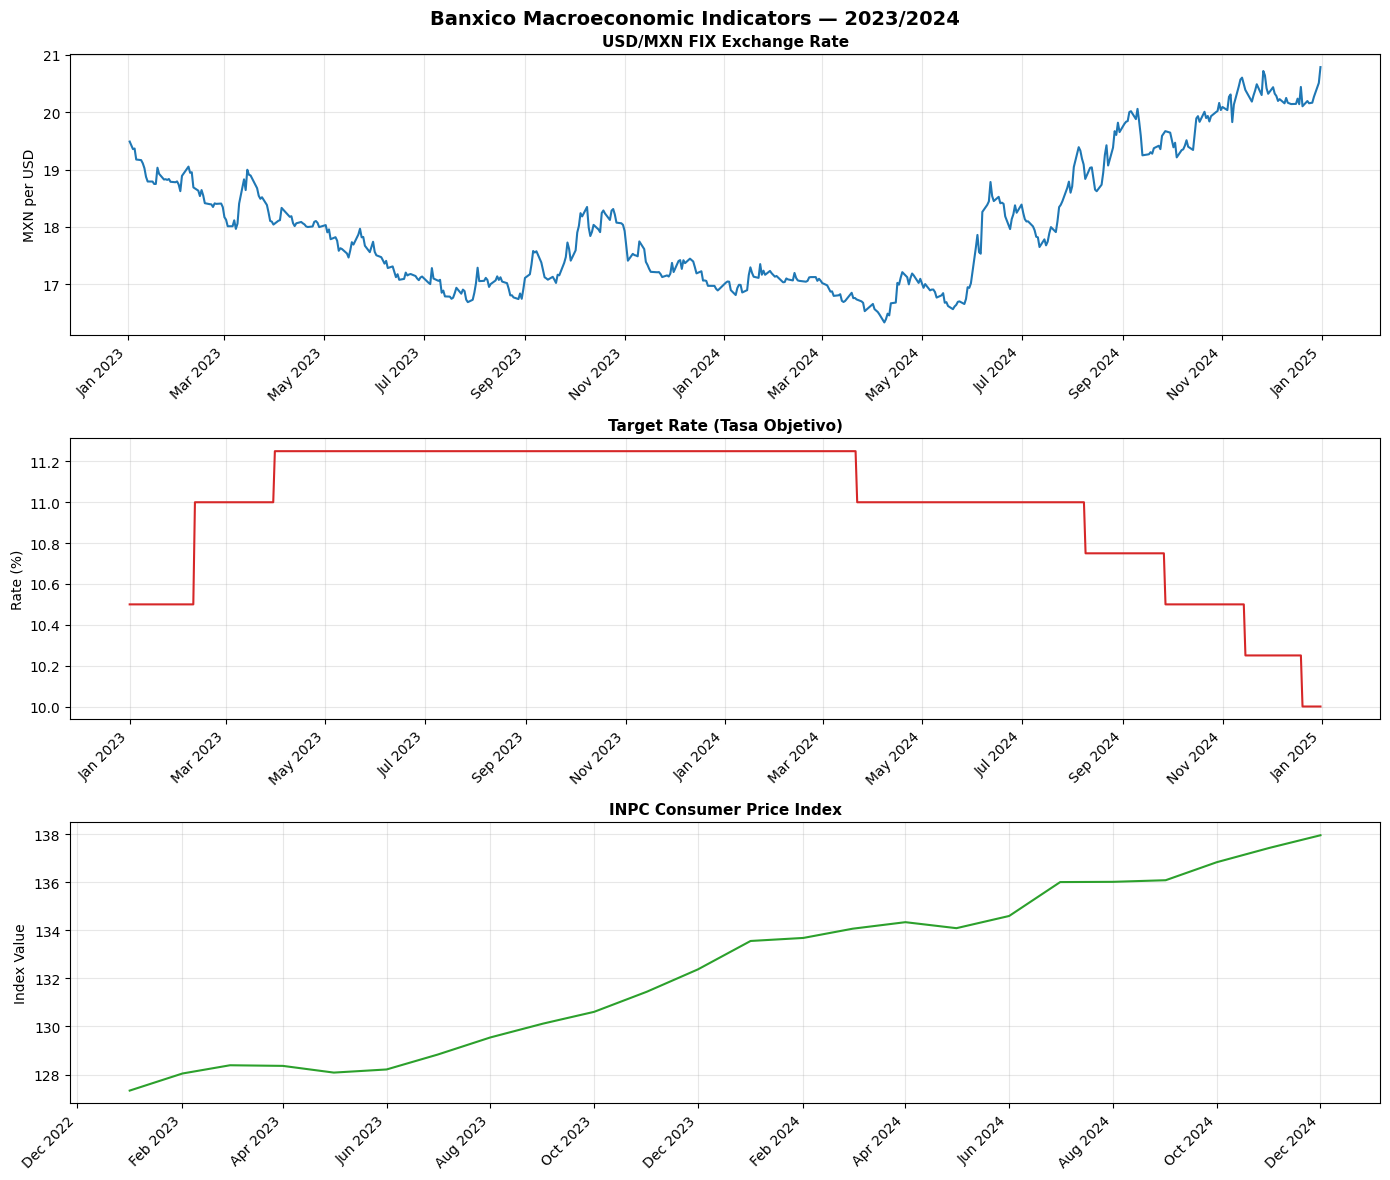

Chart saved → notebooks/banxico_indicators_2023_2024.png


In [18]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle("Banxico Macroeconomic Indicators — 2023/2024", fontsize=14, fontweight="bold")

plot_config = [
    ("tipo_de_cambio", "USD/MXN FIX Exchange Rate",  "MXN per USD",  "#1f77b4"),
    ("tiie_28",        "Target Rate (Tasa Objetivo)", "Rate (%)",     "#d62728"),
    ("inpc",           "INPC Consumer Price Index",   "Index Value",  "#2ca02c"),
]

for ax, (serie_name, title, ylabel, color) in zip(axes, plot_config):
    df = dfs[serie_name]
    ax.plot(df["date"], df["value"], color=color, linewidth=1.5, label=serie_name)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("banxico_indicators_2023_2024.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → notebooks/banxico_indicators_2023_2024.png")

## 5. Silver Layer — Transformation Decisions

Based on this exploration, the following transformations are required in Silver:

In [19]:
decisions = {
    "date_format": {
        "observation": "Banxico returns dates as dd/mm/yyyy strings",
        "silver_action": "Parse to datetime64[ns], store as DATE in Parquet",
    },
    "value_type": {
        "observation": "All values returned as strings",
        "silver_action": "Cast to float64. Nulls from failed cast → flag as data quality issue",
    },
    "tiie_weekends": {
        "observation": "SF61745 includes Saturday and Sunday with same value as Friday",
        "silver_action": "Filter to business days only — align with FIX exchange rate calendar",
    },
    "inpc_precision": {
        "observation": "SP1 returns 12 decimal places (e.g. 133.555000000000)",
        "silver_action": "Round to 6 decimal places — sufficient for inflation index",
    },
    "titulo_whitespace": {
        "observation": "titulo field contains irregular whitespace and formatting",
        "silver_action": "Normalize with str.strip() + re.sub for multiple spaces",
    },
    "missing_values": {
        "observation": "Banxico uses 'N/E' for unavailable data points",
        "silver_action": "Replace 'N/E' with null before numeric cast",
    },
    "inpc_lag": {
        "observation": "SP1 for current month not available until ~15 days after month-end",
        "silver_action": "Extract previous closed month only — never current month",
    },
}

print("Silver Layer Transformation Decisions")
print("=" * 60)
for key, decision in decisions.items():
    print(f"\n[{key}]")
    print(f"  Observation   : {decision['observation']}")
    print(f"  Silver action : {decision['silver_action']}")

Silver Layer Transformation Decisions

[date_format]
  Observation   : Banxico returns dates as dd/mm/yyyy strings
  Silver action : Parse to datetime64[ns], store as DATE in Parquet

[value_type]
  Observation   : All values returned as strings
  Silver action : Cast to float64. Nulls from failed cast → flag as data quality issue

[tiie_weekends]
  Observation   : SF61745 includes Saturday and Sunday with same value as Friday
  Silver action : Filter to business days only — align with FIX exchange rate calendar

[inpc_precision]
  Observation   : SP1 returns 12 decimal places (e.g. 133.555000000000)
  Silver action : Round to 6 decimal places — sufficient for inflation index

[titulo_whitespace]
  Observation   : titulo field contains irregular whitespace and formatting
  Silver action : Normalize with str.strip() + re.sub for multiple spaces

[missing_values]
  Observation   : Banxico uses 'N/E' for unavailable data points
  Silver action : Replace 'N/E' with null before numeric cast

In [20]:
def get_last_closed_month_window(execution_date: datetime) -> tuple[str, str]:

    first_day_current_month = execution_date.replace(day=1)
    last_day_previous_month = first_day_current_month - timedelta(days=1)
    first_day_previous_month = last_day_previous_month.replace(day=1)

    return first_day_previous_month.strftime("%Y-%m-%d"), last_day_previous_month.strftime("%Y-%m-%d")

## Next Steps

- [ ] Implement Silver transformation in `src/transform/silver.py`
- [ ] Apply schema enforcement with explicit dtypes
- [ ] Write Great Expectations suite based on ranges observed here
- [ ] Store Silver as Parquet partitioned by `year` / `month`